<a href="https://colab.research.google.com/github/muhsinasafeeth/Temperature-Prediction-using-RNN/blob/main/Temperature_prediction_using_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Import Libraries
We start by importing essential Python libraries:
- **NumPy & Pandas** for data handling
- **Matplotlib & Seaborn** for visualization
- **Scikit-learn** for preprocessing and metrics
- **TensorFlow/Keras** for building the RNN model


In [2]:
# Cell 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout


### Step 2: Load Dataset
We load the daily climate dataset (from Kaggle).  
- Display the first 10 rows to understand the structure.  
- Columns include **date, temperature, humidity, wind speed**.


In [3]:
import json

# Replace with your Kaggle API credentials
kaggle_config = {
    "username": "vsmuhsina",
    "key": "KGAT_4b8c1bb5f9e2c1634ec5cba4004b1230"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json created successfully")

kaggle.json created successfully


In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [5]:
!pip install -q kaggle

### Step 3: Explore Dataset

Plot temperature trends over time to visualize seasonality.

Check for missing values to ensure data quality.

In [6]:
# temperature data set
!kaggle datasets download -d muthuj7/weather-dataset

Dataset URL: https://www.kaggle.com/datasets/muthuj7/weather-dataset
License(s): CC0-1.0
100% 2.23M/2.23M [00:00<00:00, 3.64MB/s]



In [7]:
!unzip weather-dataset.zip

Archive:  weather-dataset.zip
  inflating: weatherHistory.csv      


In [8]:
df = pd.read_csv("weatherHistory.csv")
df.head(10)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


/tmp/ipykernel_16470/447710833.py:9: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['formatted_date'] = pd.to_datetime(df['Formatted Date'])


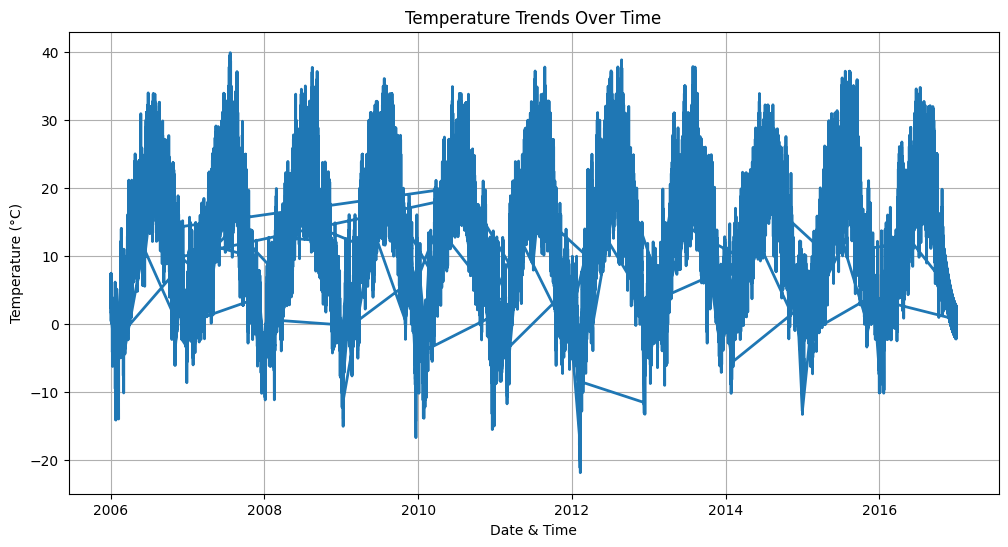

In [12]:
import pandas as pd
import matplotlib.pyplot as plt


# Parse the datetime column
df['formatted_date'] = pd.to_datetime(df['Formatted Date'])

# Set datetime as index (optional, useful for time series)
df.set_index('formatted_date', inplace=True)

# Plot temperature trends
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Temperature (C)'], color='tab:blue', linewidth=2)

# Add labels and title
plt.xlabel('Date & Time')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Trends Over Time')
plt.grid(True)
plt.show()


The line oscillates regularly, with peaks in summer (around 30–40 °C) and troughs in winter (down to –20 °C).

This repeating up-and-down pattern indicates strong seasonality in the data — temperatures rise and fall in a predictable yearly cycle.

In [18]:
# Check missing values
df.isnull().sum()


,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


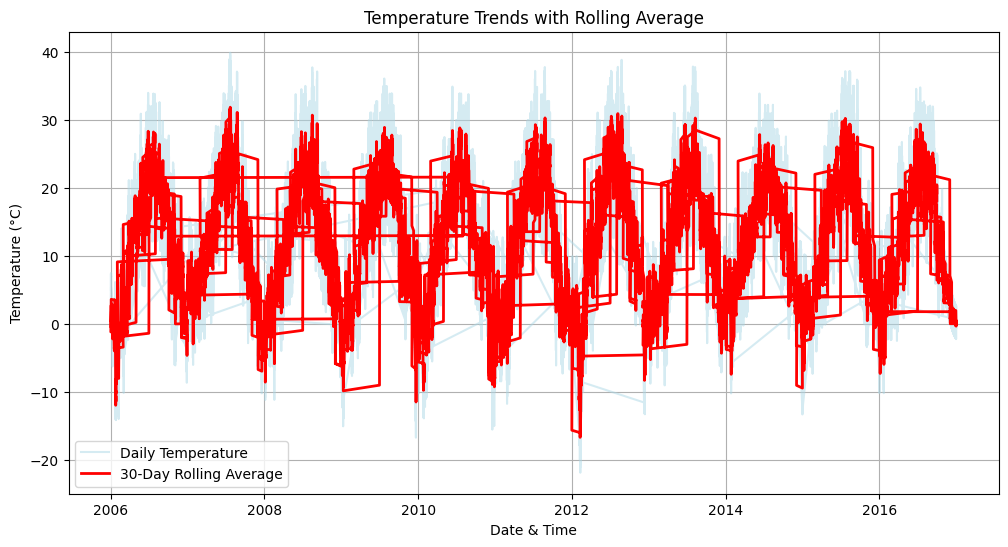

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df already has datetime index and temperature column
# Apply a rolling mean (e.g., 30 days)
df['rolling_temp'] = df['Temperature (C)'].rolling(window=30).mean()

# Plot both raw and smoothed temperature
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Temperature (C)'], color='lightblue', alpha=0.5, label='Daily Temperature')
plt.plot(df.index, df['rolling_temp'], color='red', linewidth=2, label='30-Day Rolling Average')

plt.xlabel('Date & Time')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Trends with Rolling Average')
plt.legend()
plt.grid(True)
plt.show()



### Step 4: Preprocessing
- Remove missing values.  
- Select relevant features: temperature, humidity, wind speed.  
- Normalize values using **MinMaxScaler** (important for RNN convergence).  
- Create input sequences of past 14 days to predict the next day’s temperature.  
- Split into train, validation, and test sets.


### Part B: RNN Model Development

In [21]:
# Cell 4: Preprocessing
# Handle missing values (drop or impute)
df = df.dropna()

# Select features
features = ['Temperature (C)','Humidity','Wind Speed (km/h)']
data = df[features].values

# Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Function to create sequences
def create_sequences(dataset, seq_length=14):
    X, y = [], []
    for i in range(len(dataset)-seq_length):
        X.append(dataset[i:i+seq_length])
        y.append(dataset[i+seq_length,0])  # target = temperature
    return np.array(X), np.array(y)

SEQ_LEN = 14
X, y = create_sequences(scaled_data, SEQ_LEN)

# Train/Val/Test split
train_size = int(0.7*len(X))
val_size = int(0.15*len(X))

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]


### Step 5: Build SimpleRNN Model
- Input shape = (sequence length, number of features).  
- **SimpleRNN layer** with 64 units captures temporal dependencies.  
- **Dropout** prevents overfitting.  
- **Dense layer** outputs a single value (temperature).


In [22]:
# Cell 5: Build SimpleRNN model
model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(SEQ_LEN, len(features))),
    Dropout(0.2),
    Dense(1, activation='linear')
])

# Compile
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

### Step 6: Train Model
- Train for 50 epochs with batch size 32.  
- Monitor validation loss to avoid overfitting.  
- Plot training vs validation loss curves.


Epoch 1/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0047 - mae: 0.0472 - val_loss: 5.2271e-04 - val_mae: 0.0160
Epoch 2/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.0015 - mae: 0.0289 - val_loss: 5.5602e-04 - val_mae: 0.0177
Epoch 3/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0010 - mae: 0.0230 - val_loss: 4.8107e-04 - val_mae: 0.0156
Epoch 4/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 8.1606e-04 - mae: 0.0203 - val_loss: 4.5589e-04 - val_mae: 0.0149
Epoch 5/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 7.5087e-04 - mae: 0.0192 - val_loss: 3.9010e-04 - val_mae: 0.0135
Epoch 6/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 7.2539e-04 - mae: 0.0188 - val_loss: 3.9752e-04 - val_mae: 0.0135
Epoch 7/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 7.1485e-04 - mae: 0.0187 - val_loss: 3.8062e-04 - val_mae: 0.0134
Epoch 8/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 7.1182e-04 - mae: 0.0186 - val_loss: 3.9538e-0

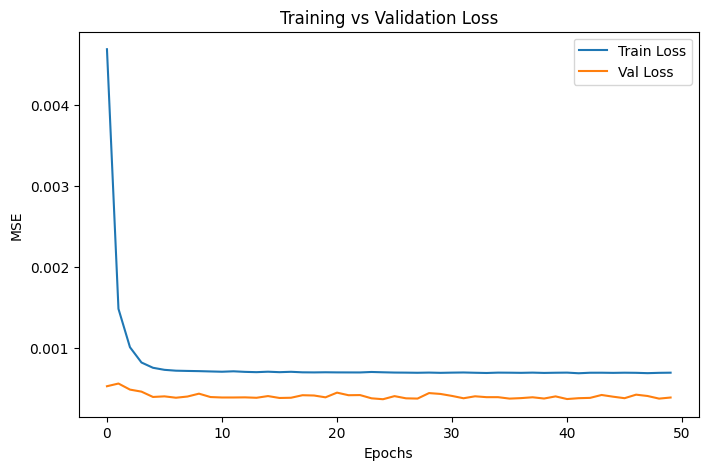

In [23]:
# Cell 6: Train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Plot training vs validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.show()


Epoch 1/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 6.8825e-04 - mae: 0.0181 - val_loss: 4.2745e-04 - val_mae: 0.0151
Epoch 2/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 6.9146e-04 - mae: 0.0182 - val_loss: 3.6613e-04 - val_mae: 0.0130
Epoch 3/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 6.8490e-04 - mae: 0.0181 - val_loss: 3.8498e-04 - val_mae: 0.0137
Epoch 4/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 6.8830e-04 - mae: 0.0181 - val_loss: 3.7903e-04 - val_mae: 0.0128
Epoch 5/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 6.8214e-04 - mae: 0.0180 - val_loss: 4.4985e-04 - val_mae: 0.0147
Epoch 6/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 6.9070e-04 - mae: 0.0181 - val_loss: 3.7051e-04 - val_mae: 0.0126
Epoch 7/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 6.8797e-04 - mae: 0.0181 - val_loss: 3.7723e-04 - val_mae: 0.0132
Epoch 8/50
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 6.8993e-04 - mae: 0.0181 - val_los

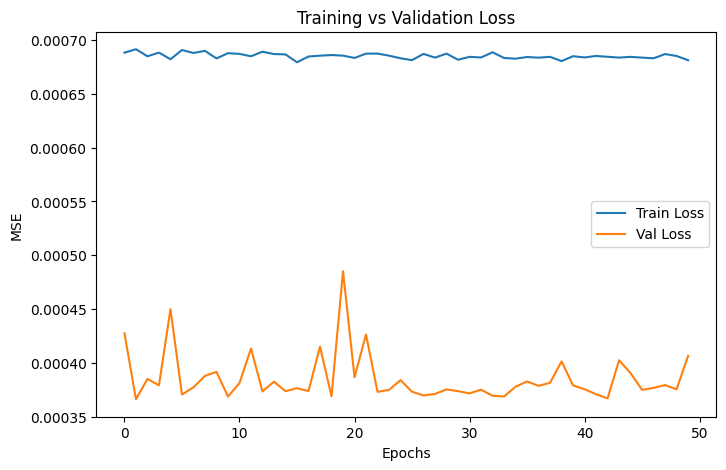

In [24]:
# Cell 6: Train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Plot training vs validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.show()


Part C: Model Evaluation & Forecasting

### Step 7: Evaluate Model
- Predict on test set.  
- Inverse scale predictions to original temperature units.  
- Compute **RMSE, MAE, R²**.  
- Plot predicted vs actual temperatures.


450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
RMSE: 1.22, MAE: 0.82, R2: 0.98


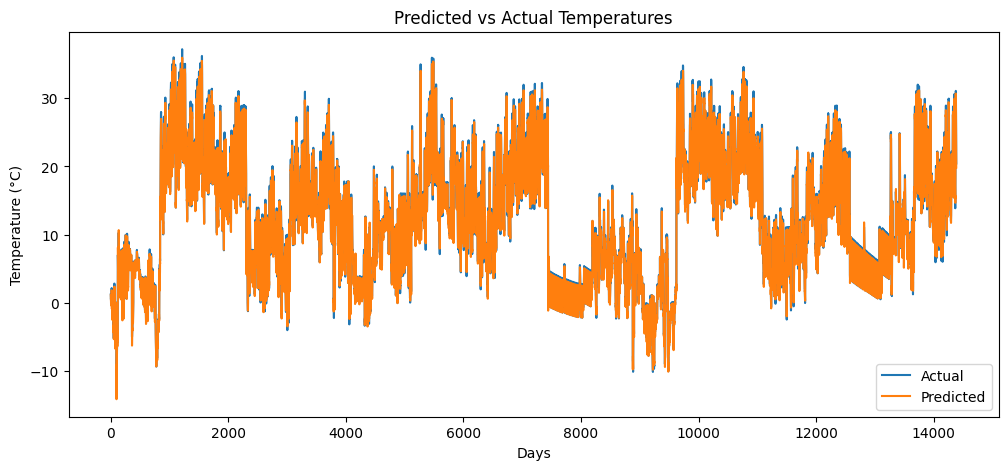

In [25]:
# Cell 7: Evaluate on test set
y_pred = model.predict(X_test)

# Inverse scaling
y_test_rescaled = scaler.inverse_transform(np.concatenate([y_test.reshape(-1,1),
                                                           np.zeros((len(y_test),2))], axis=1))[:,0]
y_pred_rescaled = scaler.inverse_transform(np.concatenate([y_pred,
                                                           np.zeros((len(y_pred),2))], axis=1))[:,0]

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")

# Plot predicted vs actual
plt.figure(figsize=(12,5))
plt.plot(y_test_rescaled, label='Actual')
plt.plot(y_pred_rescaled, label='Predicted')
plt.title("Predicted vs Actual Temperatures")
plt.xlabel("Days")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()


### Step 8: Forecast Next 7 Days
- Use the last sequence from test data.  
- Iteratively predict next day’s temperature and update sequence.  
- Plot 7-day forecast.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


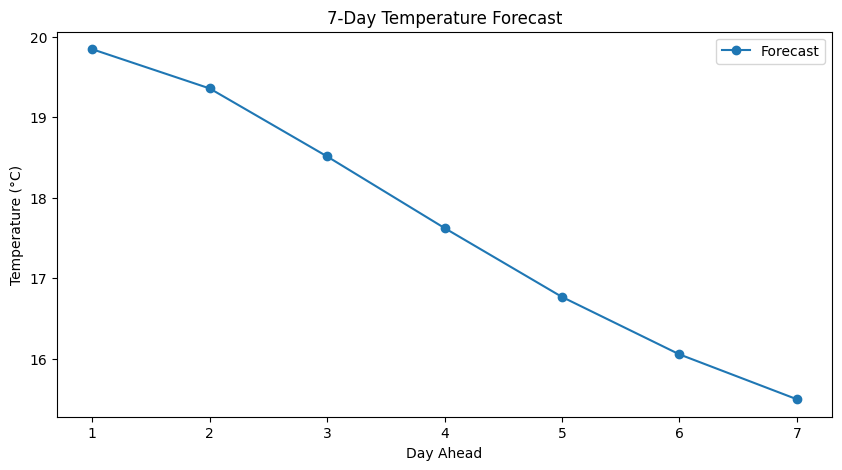

In [26]:
# Cell 8: Forecast next 7 days
last_seq = X_test[-1]  # last sequence from test
forecast = []

current_seq = last_seq
for _ in range(7):
    pred = model.predict(current_seq.reshape(1,SEQ_LEN,len(features)))
    forecast.append(pred[0,0])
    # update sequence with predicted temperature + dummy humidity/wind
    new_entry = np.array([pred[0,0], 0, 0])  # humidity/wind placeholders
    current_seq = np.vstack([current_seq[1:], new_entry])

# Inverse scale forecast
forecast_rescaled = scaler.inverse_transform(np.concatenate([np.array(forecast).reshape(-1,1),
                                                             np.zeros((len(forecast),2))], axis=1))[:,0]

plt.figure(figsize=(10,5))
plt.plot(range(1,8), forecast_rescaled, marker='o', label='Forecast')
plt.title("7-Day Temperature Forecast")
plt.xlabel("Day Ahead")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()
